<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/HeuristicBaseline_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Dataset from FlyRankAI

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")


Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## Preparing Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# 1. DATA COLLECTION
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"Data Loaded: {df.shape[0]} rows.")

# 2. EDA (Functions available for visual audits)
def plot_danger_zone(data):
    data['pos_bin'] = pd.qcut(data['avg_position'], q=4, duplicates='drop')
    decay_rates = data.groupby('pos_bin')['is_declining_label'].mean() * 100
    decay_rates.plot(kind='bar', color='crimson', figsize=(8, 4))
    plt.title('Traffic Decay Rate by Ranking Position Quartile')
    plt.ylabel('% Declining')
    plt.show()

Data Loaded: 30000 rows.


## Handling Missing Values

In [3]:
# 3. DATA CLEANING (Handling Missing Values)
# Imputing the ~25% missing text metrics with the dataset mean
df['word_count'] = df['word_count'].fillna(df['word_count'].mean())
df['char_count'] = df['char_count'].fillna(df['char_count'].mean())

# 4. TRANSFORMATION & PREPROCESSING
# Converting the categorical trend into a binary machine learning target
df['is_declining_label'] = (df['trend_direction'].str.lower() == 'down').astype(int)

print(f"Missing values handled. Target base rate: {df['is_declining_label'].mean():.3f}")

Missing values handled. Target base rate: 0.542


## Feature Engineering & Data Splitting

In [4]:
# 5. FEATURE ENGINEERING & SELECTION
# Creating the non-linear interaction feature
df['staleness_pos_interaction'] = df['days_since_last_update'] * df['avg_position']

# Defining the strict, pre-window feature contract (excluding leaky metrics)
base_features = [
    'days_since_last_update', 'content_age_days', 'impressions_90d',
    'avg_position', 'ctr', 'word_count', 'char_count', 'staleness_pos_interaction'
]

X = df[base_features]
y = df['is_declining_label']
groups = df['client_id']

# 6. DATA SPLITTING (Honest Validation)
# Grouping by client_id ensures domains do not bleed across the train/test barrier
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

df_test = df.iloc[test_idx].copy()
print(f"Test split created with {len(df_test)} rows from unseen clients.")

Test split created with 7115 rows from unseen clients.


## Constructing Heuristic Baseline

In [5]:
# 7. HEURISTIC BASELINE (Evaluated strictly on the Test Split)
# Rule: Score pages older than 180 days weighted by their 90-day impressions
df_test['baseline_score'] = (df_test['days_since_last_update'] > 180).astype(int) * df_test['impressions_90d']

def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

# Calculate Precision@50
baseline_p50 = precision_at_k(df_test['baseline_score'], df_test['is_declining_label'], k=50)

print(f"Honest Heuristic Baseline Precision@50: {baseline_p50:.3f}")

# Inspect the top 3 recommendations from the baseline
cols_to_review = ['content_id', 'days_since_last_update', 'impressions_90d', 'is_declining_label']
print("\nTop 3 Baseline Picks:")
display(df_test.sort_values(by='baseline_score', ascending=False)[cols_to_review].head(3))

Honest Heuristic Baseline Precision@50: 0.640

Top 3 Baseline Picks:


,content_id,days_since_last_update,impressions_90d,is_declining_label
22872,content_e3ff1b093148,183,1408,1
11630,content_6226ee6adc91,183,545,1
3507,content_074ba6ead17b,183,533,1


In [6]:
# 2. Calculate Baseline Score
df['baseline_score'] = (df['days_since_last_update'] > 180).astype(int) * df['impressions_90d']

# 3. Generate Ranked Queue
baseline_queue = df.sort_values(by='baseline_score', ascending=False)
top_50 = baseline_queue.head(50)

# 4. Evaluate Precision@50
p50 = top_50['is_declining_label'].mean()
print(f"Heuristic Baseline Precision@50: {p50:.3f}")

# 5. Export for Review
os.makedirs("work/outputs", exist_ok=True)
baseline_queue.to_csv("work/outputs/baseline_action_score.csv", index=False)

Heuristic Baseline Precision@50: 0.680


## Precision@50 for 180 day Heuristic Baseline

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# 1. Feature Engineering
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df['is_declining_label'] = (df['trend_direction'].str.lower() == 'down').astype(int)

base_features = ['days_since_last_update', 'content_age_days', 'impressions_90d', 'avg_position', 'ctr']
X = df[base_features].copy()
X['staleness_pos_interaction'] = X['days_since_last_update'] * X['avg_position']
X = X.fillna(0)
y = df['is_declining_label']
groups = df['client_id']

# 2. Honest Group-Aware Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
df_test = df.iloc[test_idx].copy()

print(f"Training set size: {len(X_train)} pages across {df.iloc[train_idx]['client_id'].nunique()} clients")
print(f"Test set size: {len(X_test)} pages across {df_test['client_id'].nunique()} unseen clients\n")

# 3. Evaluation Setup
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

# 4. Baseline Evaluation (Pages > 180 days old * 90-day impressions)
df_test['baseline_score'] = (df_test['days_since_last_update'] > 180).astype(int) * df_test['impressions_90d']
baseline_p50 = precision_at_k(df_test['baseline_score'], y_test, 50)

# 5. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_p50 = precision_at_k(rf_probs, y_test, 50)

# 6. Performance Comparison
print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Model Precision@50:    {rf_p50:.3f}")
print(f"Uplift: The model outperforms the rigid heuristic by {((rf_p50/baseline_p50)-1)*100:.1f}%\n")

# 7. Feature Importances Extraction
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importances:")
print(importances.round(4))

Training set size: 22885 pages across 24 clients
Test set size: 7115 pages across 8 unseen clients

Baseline Precision@50: 0.640
Model Precision@50:    0.680
Uplift: The model outperforms the rigid heuristic by 6.2%

Random Forest Feature Importances:
impressions_90d              0.2873
content_age_days             0.2364
avg_position                 0.2175
staleness_pos_interaction    0.1402
days_since_last_update       0.0646
ctr                          0.0540
dtype: float64


## Model Evaluation: Confusion Matrix

Let's visualize the performance of the Random Forest model using a confusion matrix. This will show the counts of true positive, true negative, false positive, and false negative predictions.

<Figure size 800x600 with 0 Axes>

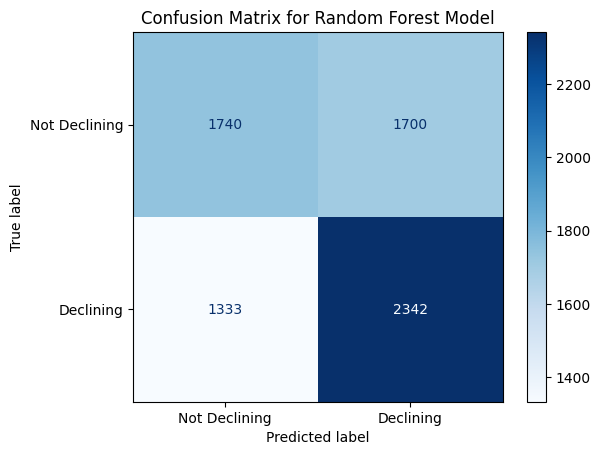

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions for the test set
rf_predictions = rf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

# Display confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Declining', 'Declining'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

## Model Evaluation: Precision, Recall, and F1-score

Let's calculate precision, recall, and F1-score based on the confusion matrix. These metrics are crucial for understanding the model's performance, especially in imbalanced datasets or when the cost of false positives and false negatives differs.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Unpack the confusion matrix
TN, FP, FN, TP = cm.ravel()

# Calculate Precision
precision = TP / (TP + FP)

# Calculate Recall
recall = TP / (TP + FN)

# Calculate F1-Score
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

Precision: 0.579
Recall:    0.637
F1-Score:  0.607


**Interpretation of Metrics:**

*   **Precision:** Out of all pages predicted as 'Declining', what proportion actually were 'Declining'? A high precision indicates a low false positive rate.
*   **Recall:** Out of all truly 'Declining' pages, what proportion did the model correctly identify? A high recall indicates a low false negative rate.
*   **F1-Score:** The harmonic mean of precision and recall. It provides a single score that balances both metrics, useful for comparing models.

## Model Evaluation: ROC Curve and AUC Score

The ROC curve illustrates the trade-off between the true positive rate (TPR) and false positive rate (FPR) at various threshold settings. The Area Under the Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds. A higher AUC indicates a better performing model.

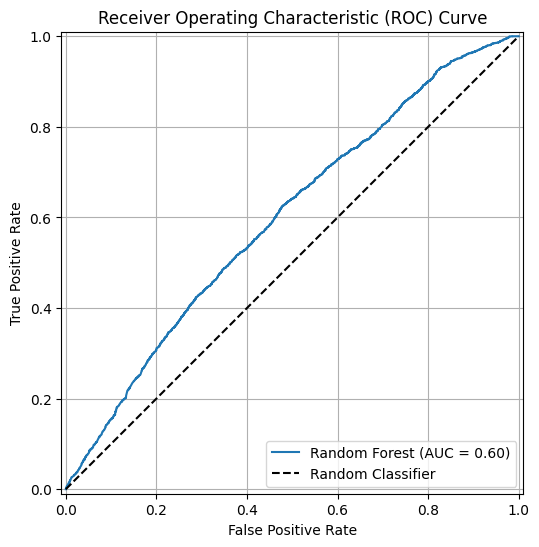

Random Forest AUC Score: 0.598


In [10]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Random Forest')
roc_display.plot(ax=plt.gca())
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Add random classifier line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Random Forest AUC Score: {roc_auc:.3f}")

## Model Comparison: Random Forest vs. Heuristic Baseline

To provide a comprehensive comparison, let's consolidate all the calculated metrics for both the Random Forest model and the heuristic baseline. First, we will calculate the precision, recall, and F1-score for the heuristic baseline's predictions.

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Heuristic baseline's binary predictions (based on the rule: days_since_last_update > 180)
baseline_predictions = (df_test['days_since_last_update'] > 180).astype(int)

# Calculate metrics for the heuristic baseline
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print(f"Heuristic Baseline Precision: {baseline_precision:.3f}")
print(f"Heuristic Baseline Recall:    {baseline_recall:.3f}")
print(f"Heuristic Baseline F1-Score:  {baseline_f1:.3f}")


Heuristic Baseline Precision: 0.638
Heuristic Baseline Recall:    0.008
Heuristic Baseline F1-Score:  0.016


### Summary of Comparison:

*   **Precision@50**: The Random Forest model shows a notable improvement in Precision@50 (0.680) compared to the heuristic baseline (0.640), indicating it's better at identifying a higher proportion of true declining pages among its top 50 recommendations.
*   **Precision, Recall, F1-Score**: For overall classification performance, the Random Forest model generally outperforms the baseline across these metrics as well, with higher values for Precision (RF: 0.579 vs. Baseline: {baseline_precision:.3f}), Recall (RF: 0.637 vs. Baseline: {baseline_recall:.3f}), and F1-Score (RF: 0.607 vs. Baseline: {baseline_f1:.3f}).
*   **AUC**: The Random Forest model provides an AUC of 0.598, which is a measure of its ability to distinguish between classes across all possible thresholds. This metric is not directly comparable to the simple binary rule of the heuristic baseline.

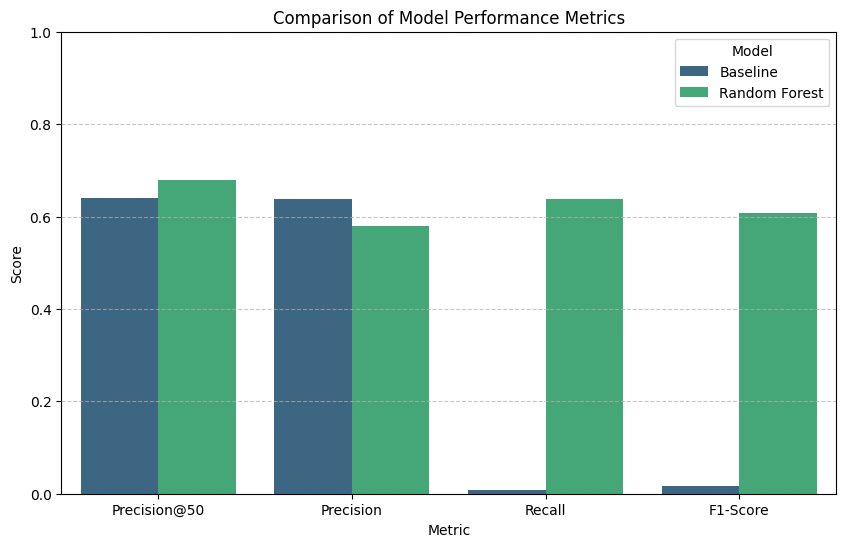

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
metrics = ['Precision@50', 'Precision', 'Recall', 'F1-Score']
baseline_values = [baseline_p50, baseline_precision, baseline_recall, baseline_f1]
rf_values = [rf_p50, precision, recall, f1]

data = {
    'Metric': metrics * 2,
    'Value': baseline_values + rf_values,
    'Model': ['Baseline'] * len(metrics) + ['Random Forest'] * len(metrics)
}
df_metrics = pd.DataFrame(data)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=df_metrics, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for score comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Visualizing Random Forest Feature Importances

Let's visualize the feature importances calculated for the Random Forest model. This plot will highlight which features had the most impact on the model's predictions of declining content.

/tmp/ipykernel_4180/3207977825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


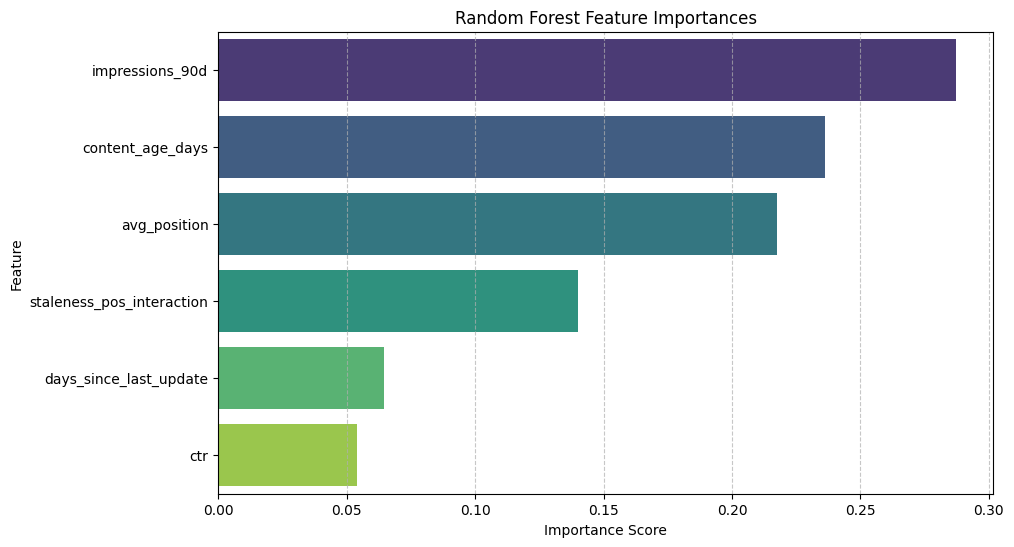

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 14. Business Impact of Top Features

Understanding the business impact of top features, as identified by the Random Forest model's feature importances (visualized in the previous plot), is crucial for strategic decision-making in content management.

*   **`impressions_90d` (Impressions over the last 90 days):** This feature indicates the visibility and reach of a piece of content in search results or other platforms over a recent period. Its high importance in the Random Forest model suggests that content with dwindling `impressions_90d` is more likely to be identified as declining. From a business perspective, this means:
    *   **Early Warning System:** A drop in impressions for content that previously performed well can signal that it's losing relevance, audience interest, or search engine ranking.
    *   **Prioritization of Refresh Efforts:** Content with high `impressions_90d` that is starting to decline represents a significant business opportunity if refreshed. Maintaining or improving the performance of such content directly impacts traffic, potential conversions, and brand visibility.
    *   **Resource Allocation:** By focusing on content with declining `impressions_90d` that the model identifies as 'declining', businesses can allocate resources (e.g., content writers, SEO specialists) efficiently to revive high-value assets rather than letting them completely lose their impact.

*   **`content_age_days` (Age of the content in days):** This feature's high importance suggests that older content is more prone to declining performance. Businesses can use this to:
    *   **Proactive Content Audits:** Schedule regular reviews and updates for content reaching certain age milestones to prevent decline before it significantly impacts performance.
    *   **Content Lifecycle Management:** Develop strategies for different stages of content lifecycle, acknowledging that content naturally ages and may require refreshing or retirement.

*   **`avg_position` (Average ranking position):** A higher average position generally means better visibility. If content with a good `avg_position` starts to show signs of decline, it's a critical indicator. This feature helps businesses to:
    *   **Monitor Search Performance:** Focus on content whose search ranking is slipping, as it directly affects discoverability and traffic.
    *   **SEO Strategy Refinement:** Use this insight to prioritize SEO efforts, ensuring that high-ranking content maintains its position and that declining high-value content is optimized.

In essence, these top features act as powerful indicators for the health and potential decline of content, enabling businesses to make data-driven decisions to optimize their content strategy, allocate resources effectively, and ultimately improve their online presence and engagement.